### Introduction to 3D Protein Structures with BioPython

In [14]:
from Bio.PDB import PDBParser

# Initialize the parser
parser = PDBParser()

# Load the structure (id, filename)
structure = parser.get_structure("1FAT", "1fat.pdb")

# Let's explore the hierarchy
for model in structure:
    for chain in model:
        print(f"Chain ID: {chain.id}")
        # Let's just look at the first 5 residues of the first chain
        residues = list(chain.get_residues())
        for res in residues[:5]:
            print(f"  Residue: {res.get_resname()} {res.id[1]}")

Chain ID: A
  Residue: SER 1
  Residue: ASN 2
  Residue: ASP 3
  Residue: ILE 4
  Residue: TYR 5
Chain ID: B
  Residue: SER 1
  Residue: ASN 2
  Residue: ASP 3
  Residue: ILE 4
  Residue: TYR 5
Chain ID: C
  Residue: SER 1
  Residue: ASN 2
  Residue: ASP 3
  Residue: ILE 4
  Residue: TYR 5
Chain ID: D
  Residue: SER 1
  Residue: ASN 2
  Residue: ASP 3
  Residue: ILE 4
  Residue: TYR 5


c:\SWANKY\YouTube Channels\Code Swanky\Bioinformatics\.venv\Lib\site-packages\Bio\PDB\StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 7979.
  warnings.warn(
c:\SWANKY\YouTube Channels\Code Swanky\Bioinformatics\.venv\Lib\site-packages\Bio\PDB\StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 7995.
  warnings.warn(
c:\SWANKY\YouTube Channels\Code Swanky\Bioinformatics\.venv\Lib\site-packages\Bio\PDB\StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain C is discontinuous at line 8011.
  warnings.warn(
c:\SWANKY\YouTube Channels\Code Swanky\Bioinformatics\.venv\Lib\site-packages\Bio\PDB\StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain D is discontinuous at line 8027.
  warnings.warn(
c:\SWANKY\YouTube Channels\Code Swanky\Bioinformatics\.venv\Lib\site-packages\Bio\PDB\StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 8043.
  warnings.warn(


In [15]:
# Select the first residue in the first chain
first_residue = structure[0]['A'][1] 

# Get the Carbon-Alpha atom
ca_atom = first_residue['CA']

print(f"Atom: {ca_atom.get_name()}")
print(f"3D Coordinates: {ca_atom.get_vector()}")

Atom: CA
3D Coordinates: <Vector 23.46, 11.02, 31.70>


In [24]:
# Get two different atoms
res1 = structure[0]['A'][1]['CA']
res10 = structure[0]['A'][10]['CA']

# Calculate distance in Angstroms
distance = res1 - res10

print(f"The distance between Residue 1 and Residue 10 is: {distance:.2f} Å")

The distance between Residue 1 and Residue 10 is: 27.80 Å


### Protein-Protein Interactions (PPI) with NetworkX

In [19]:
# Install NetworkX
!pip install networkx


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import networkx as nx
import matplotlib.pyplot as plt

In [21]:
# 1. Create an empty Graph object
G = nx.Graph()

# 2. Add interactions (Edges)
# Let's say P1 is a "Hub" interacting with everyone
interactions = [("P1", "P2"), ("P1", "P3"), ("P1", "P4"), ("P1", "P5"), ("P2", "P3")]
G.add_edges_from(interactions)

print(f"Nodes in the network: {G.nodes()}")
print(f"Number of interactions: {G.number_of_edges()}")

Nodes in the network: ['P1', 'P2', 'P3', 'P4', 'P5']
Number of interactions: 5


In [22]:
# Calculate the degree of each protein
for protein, degree in G.degree():
    print(f"Protein {protein} has {degree} connections.")

Protein P1 has 4 connections.
Protein P2 has 2 connections.
Protein P3 has 2 connections.
Protein P4 has 1 connections.
Protein P5 has 1 connections.


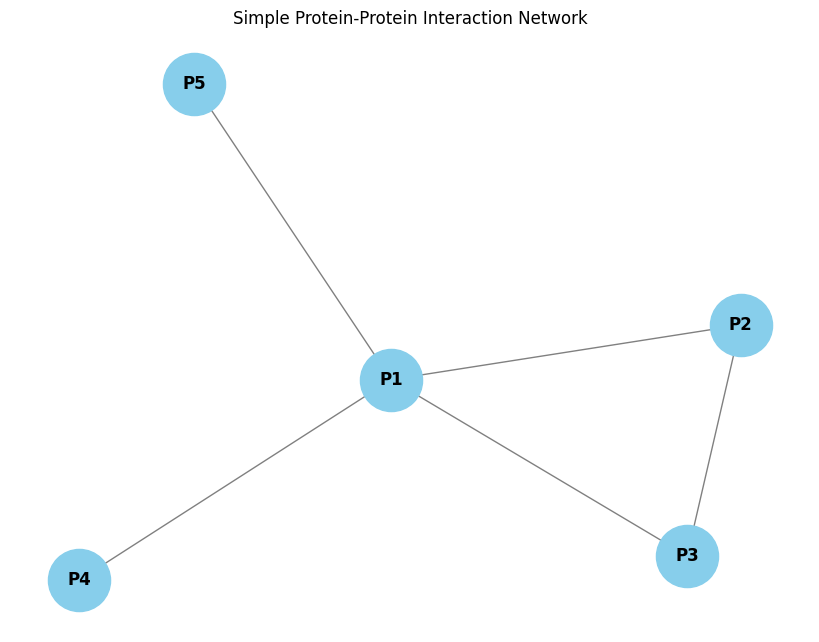

In [23]:
# Set a layout (spring layout makes it look 'organic')
pos = nx.spring_layout(G)

# Draw the network
plt.figure(figsize=(8, 6))
nx.draw(G, pos, with_labels=True, 
        node_color='skyblue', 
        node_size=2000, 
        edge_color='gray', 
        font_weight='bold')

plt.title("Simple Protein-Protein Interaction Network")
plt.show()